# Word2Vec 

"*Dime con quien andas y te diré quién eres*" - [Francisco de Quevedo en el siglo XVI](https://significalogia.com/dime-con-quien-andas-y-te-dire-quien-eres-significado-y-origen-de-este-refran/)
                                
*Word2Vec* es una técnica de **Procesamiento del Lenguaje Natural** (*NLP*) utilizada para representar palabras como vectores (en un **espacio continuo**) de características numéricas de baja dimensión. Este método, desarrollado por un equipo de Google dirigido por Tomas Mikolov en 2013, ha revolucionado la forma en que se representan las palabras en el espacio vectorial, permitiendo que las máquinas comprendan y procesen el texto de una manera más eficiente y efectiva.

*Word2Vec* utiliza dos arquitecturas principales para aprender las representaciones de las palabras:

1. **CBOW** (Continuous Bag of Words): Predice una palabra objetivo basada en su contexto circundante. Es decir, toma las palabras del contexto y trata de predecir la palabra central.
1. **Skip-gram**: Predice el contexto de una palabra objetivo. Toma una palabra central y trata de predecir las palabras circundantes en el contexto.

Ambos métodos se basan en redes neuronales simples y generan vectores de palabras que capturan las **relaciones semánticas** entre ellas.

El supuesto más importante de *Word2Vec* es que 2 palabras que tienen un **contexto similar**, entonces deben tener un **significado similar**, por ende, una representación vectorial similar.

Por ejemplo, palabras como "*perro*", "*cachorro*", "*mascota*" suelen estar en contextos similares, por ende su representación vectorial en *Word2Vec* debe ser similar. Es posible llegar a este tipo de conclusiones, gracias a que *Word2Vec* captura las relaciones semánticas entre palabras en base a los patrones descubiertos en la co-ocurrencia  de palabras dado un corpus.

# Load data

In [1]:
import itertools as it
from gensim.models.word2vec import LineSentence

c:\Users\eduardo.moreno\AppData\Local\anaconda3\envs\env_nlp\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
trigram_sentences_filepath = r'..\..\..\data\ngrams\full-data\trigram_sentences_all.txt'

In [3]:
trigram_sentences = LineSentence(trigram_sentences_filepath)

Algunos mensajes preprocesados son:

In [4]:
for trigram_sentence in it.islice(trigram_sentences, 123, 128):
    print(' '.join(trigram_sentence))
    print('')

compartar conocimiento idea iniciativa proyecto mejorar vida america_latino_caribe silvicultura biodiversidad desarrollo agricola turismo ciudades sostenibles mitigacion frente cambio climatico infraestructura energia desarrollo_sostenible mas suscribiendote blog bid sostenibilidad ciudad sostenible cambio climatico politica salvaguardia ambiental transporte energia agua_saneamiento mirar_video youtube tema descarga publicacion suscribete curso banco_interamericano_desarrollo bid mejorar_calidad_vida america_latino_caribe ayudar mejorar salud educacion infraestructura traves apoyo financiero tecnico pais reducir pobreza_desigualdad objetivo alcanzar desarrollo_sostenible respetuoso clima

upecista 22 estudiante ciencia politica pais juan_jose ramirez algarra dejar alto nombre unicesar competir estudiante universidad publica_privado colombia continuo excelente actividad academico juan_jose ramirez algarra estudiante 10deg semestre programa derecho universidad popular cesar codear estudi

# Word2Vec

## CBOW

In [5]:
import multiprocessing
from gensim.models import Word2Vec

In [6]:
cores = multiprocessing.cpu_count()
print(f"Number of cores available: {cores}")

Number of cores available: 16


Definir el modelo

In [7]:
%%time
if 1 == 1:
    # Definir modelo
    w2v_model = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )
    # Construir vocabulario
    w2v_model.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )
    # Entrenar el modelo
    w2v_model.train(
        trigram_sentences, 
        total_examples=w2v_model.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model.save(r"..\..\models\w2v\w2v-cbow-full-data.model")
else:
    w2v_model = Word2Vec.load(r"..\..\models\w2v\w2v-cbow-full-data.model")

CPU times: total: 6h 22min
Wall time: 31min 53s


Comportamiento

In [8]:
similar_words = w2v_model.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatica: 0.43975508213043213
climatico: 0.3667033612728119
cambioclimatico: 0.36039960384368896
fenomeno_meteorologicos: 0.31763243675231934
meteorologia: 0.3079463839530945
climate: 0.30753985047340393
temperatura: 0.30665987730026245
climatologia: 0.30640751123428345
clima_cambiante: 0.2960689067840576
accion_climatica: 0.292788565158844


In [9]:
w2v_model.wv.most_similar(positive=["cambio"])

[('climatico', 0.5843503475189209),
 ('cambioclimatico', 0.5300536751747131),
 ('calentamiento_global', 0.47973132133483887),
 ('crisis', 0.4287760257720947),
 ('efecto', 0.37269943952560425),
 ('fenomeno', 0.3288919925689697),
 ('impacto', 0.32875460386276245),
 ('emergencia', 0.3227737545967102),
 ('enterate', 0.3138926923274994),
 ('crisisclimatica', 0.3082500398159027)]

In [11]:
w2v_model.wv.most_similar(positive=["climatico"])

[('cambio', 0.5843505263328552),
 ('cambioclimatico', 0.5135532021522522),
 ('calentamiento_global', 0.4868468940258026),
 ('efecto', 0.3761913478374481),
 ('clima', 0.3667033612728119),
 ('ambiental', 0.3284352123737335),
 ('climatica', 0.3254140019416809),
 ('efecto_adverso', 0.3130556344985962),
 ('crisisclimatica', 0.3109035789966583),
 ('impacto', 0.31068548560142517)]

In [12]:
w2v_model.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.587262749671936),
 ('ambiente', 0.5287513732910156),
 ('cuidado_medio_ambiente', 0.5055996179580688),
 ('ambiental', 0.38694116473197937),
 ('recurso_natural', 0.38497090339660645),
 ('entorno_natural', 0.370423287153244),
 ('medioambiental', 0.3602927327156067),
 ('educacion_ambiental', 0.3482680022716522),
 ('ecologia', 0.34132251143455505),
 ('salud', 0.33771035075187683)]

In [13]:
w2v_model.wv.most_similar(positive=["agua"])

[('agua_potable', 0.5494289994239807),
 ('vital_liquido', 0.49988019466400146),
 ('agua_dulce', 0.4969336688518524),
 ('recurso_hidrico', 0.49348554015159607),
 ('liquido_vital', 0.4679499864578247),
 ('agua_subterraneo', 0.46270108222961426),
 ('liquido', 0.45589151978492737),
 ('agua_superficial', 0.4420390725135803),
 ('agua_subterranea', 0.42368340492248535),
 ('acuifero', 0.4236684739589691)]

In [14]:
w2v_model.wv.most_similar(positive=["sol"])

[('rayo_sol', 0.44262298941612244),
 ('radiacion', 0.43838736414909363),
 ('luz_solar', 0.41141730546951294),
 ('rayo_solar', 0.4049775004386902),
 ('solar', 0.40186649560928345),
 ('campo_magnetico', 0.39650020003318787),
 ('astro', 0.3902418911457062),
 ('luz_sol', 0.38785767555236816),
 ('brillar', 0.37516698241233826),
 ('radiacion_solar', 0.37263810634613037)]

In [15]:
w2v_model.wv.most_similar(positive=["desastre"])

[('catastrof', 0.6256330609321594),
 ('desastre_natural', 0.5980445146560669),
 ('catastrofe', 0.5572277903556824),
 ('tragedia', 0.49137699604034424),
 ('emergencia', 0.46134641766548157),
 ('catastrofes', 0.44633886218070984),
 ('calamidad', 0.4374002516269684),
 ('catastrof_natural', 0.4290686249732971),
 ('inundacion', 0.40842464566230774),
 ('desastr', 0.4079332947731018)]

In [16]:
w2v_model.wv.most_similar(positive=["desastre_natural"])

[('desastre', 0.5980445742607117),
 ('catastrof', 0.5509569048881531),
 ('catastrof_natural', 0.4877872169017792),
 ('fenomeno_natural', 0.46628323197364807),
 ('terremoto', 0.43904879689216614),
 ('inundacion', 0.43153074383735657),
 ('huracan', 0.42842742800712585),
 ('catastrofes', 0.42657992243766785),
 ('inundacion_sequia', 0.4194280803203583),
 ('evento_meteorologico_extremo', 0.41253358125686646)]

In [17]:
w2v_model.wv.most_similar(positive=["incremento"])

[('aumento', 0.8569540977478027),
 ('incrementar', 0.6099086403846741),
 ('disminucion', 0.5942650437355042),
 ('aumentar', 0.5736148953437805),
 ('alza', 0.5025637745857239),
 ('descenso', 0.48581865429878235),
 ('reduccion', 0.4699743986129761),
 ('aumento_temperatura', 0.44146573543548584),
 ('creciente', 0.42633816599845886),
 ('duplicar', 0.42515239119529724)]

In [18]:
w2v_model.wv.most_similar(positive=["temperatura"])

[('aumento_temperatura', 0.654005229473114),
 ('temperatura_maxima', 0.6510168313980103),
 ('temperatura_promedio', 0.6493368148803711),
 ('grado_centigrado', 0.6465827226638794),
 ('alto_temperatura', 0.6402649879455566),
 ('grado_celsius', 0.6277303099632263),
 ('incremento_temperatura', 0.6110691428184509),
 ('oc', 0.572487473487854),
 ('degc', 0.5639200210571289),
 ('calor', 0.5631154179573059)]

In [19]:
w2v_model.wv.most_similar(positive=["bajar"])

[('subir', 0.5609530806541443),
 ('descender', 0.4899957776069641),
 ('disminuir', 0.47921547293663025),
 ('reducir', 0.4376955032348633),
 ('elevar', 0.4106462001800537),
 ('aumentar', 0.4037156105041504),
 ('subio', 0.39887866377830505),
 ('descenso', 0.3972603380680084),
 ('caer', 0.39267468452453613),
 ('considerablemente', 0.3913058936595917)]

In [20]:
w2v_model.wv.most_similar(positive=["mas"])

[('extremadamente', 0.3772624433040619),
 ('demasiado', 0.37287357449531555),
 ('mundo', 0.33555227518081665),
 ('particularmente', 0.33160096406936646),
 ('increiblemente', 0.32013773918151855),
 ('relativamente', 0.3141021728515625),
 ('sumamente', 0.31389203667640686),
 ('especialmente', 0.31331396102905273),
 ('altamente', 0.30000966787338257),
 ('extraordinariamente', 0.29720500111579895)]

In [21]:
w2v_model.wv.most_similar(positive=["gobierno"])

[('gobierno_federal', 0.446036159992218),
 ('administracion', 0.44546759128570557),
 ('gubernamental', 0.4229012727737427),
 ('mandatario', 0.4076106548309326),
 ('autoridad', 0.39573273062705994),
 ('ejecutivo', 0.3883047103881836),
 ('gobernante', 0.3837679624557495),
 ('gobernador', 0.36315208673477173),
 ('presidente', 0.3517116904258728),
 ('electo', 0.3464563488960266)]

Similitud entre 2 tokens:

In [22]:
w2v_model.wv.similarity("incrementar", "temperatura")

0.17807655

In [23]:
w2v_model.wv.similarity("disminuir", "temperatura")

0.21851768

## Skip Gram

In [24]:
%%time
if 1 == 1:
    w2v_model_sg = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )

    w2v_model_sg.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )

    w2v_model_sg.train(
        trigram_sentences, 
        total_examples=w2v_model_sg.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model_sg.save(r"..\..\models\w2v\w2v-sg-full-data.model")
else:
    w2v_model_sg = Word2Vec.load(r"..\..\models\w2v\w2v-sg-full-data.model")

CPU times: total: 6h 6min 24s
Wall time: 29min 43s


In [25]:
similar_words = w2v_model_sg.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatica: 0.42685723304748535
climatico: 0.3585869073867798
cambioclimatico: 0.3493964672088623
temperatura: 0.3230170011520386
condicion_climatica: 0.3168655037879944
meteorologia: 0.30680033564567566
climatologia: 0.3058655858039856
accion_climatica: 0.2972561717033386
fenomeno_meteorologicos: 0.28728529810905457
medioambiente: 0.28590917587280273


In [26]:
w2v_model_sg.wv.most_similar(positive=["cambio"])

[('climatico', 0.5833017826080322),
 ('cambioclimatico', 0.5187152028083801),
 ('calentamiento_global', 0.47864028811454773),
 ('crisis', 0.4383889436721802),
 ('efecto', 0.3869314193725586),
 ('impacto', 0.3310656249523163),
 ('fenomeno', 0.3266339600086212),
 ('emergencia', 0.32426589727401733),
 ('crisisclimatica', 0.3170461356639862),
 ('efecto_adverso', 0.30881938338279724)]

In [27]:
w2v_model_sg.wv.most_similar(positive=["climatico"])

[('cambio', 0.5833017230033875),
 ('cambioclimatico', 0.5245838761329651),
 ('calentamiento_global', 0.474405974149704),
 ('efecto', 0.3838163912296295),
 ('clima', 0.35858696699142456),
 ('climatica', 0.3283272385597229),
 ('efecto_adverso', 0.32729172706604004),
 ('ambiental', 0.32625168561935425),
 ('enterate', 0.3172963559627533),
 ('crisisclimatica', 0.3158833086490631)]

In [28]:
w2v_model_sg.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.582152247428894),
 ('ambiente', 0.5282968282699585),
 ('cuidado_medio_ambiente', 0.5077873468399048),
 ('ambiental', 0.3855260908603668),
 ('recurso_natural', 0.37710022926330566),
 ('medioambiental', 0.36992010474205017),
 ('entorno_natural', 0.36890098452568054),
 ('ecologia', 0.360378623008728),
 ('educacion_ambiental', 0.33867740631103516),
 ('entorno', 0.3362153470516205)]

In [29]:
w2v_model_sg.wv.most_similar(positive=["agua"])

[('agua_potable', 0.5559175610542297),
 ('recurso_hidrico', 0.5024961233139038),
 ('vital_liquido', 0.4919278919696808),
 ('agua_dulce', 0.49093517661094666),
 ('liquido', 0.45866674184799194),
 ('liquido_vital', 0.45698246359825134),
 ('agua_subterraneo', 0.45357465744018555),
 ('agua_superficial', 0.436526894569397),
 ('acuifero', 0.4360175132751465),
 ('disponibilidad_agua', 0.42374077439308167)]

In [30]:
w2v_model_sg.wv.most_similar(positive=["mas"])

[('demasiado', 0.3931252658367157),
 ('extremadamente', 0.3726312220096588),
 ('particularmente', 0.3415200710296631),
 ('mundo', 0.3401300609111786),
 ('increiblemente', 0.3249594569206238),
 ('relativamente', 0.32441267371177673),
 ('altamente', 0.3214803636074066),
 ('suficientemente', 0.3156965672969818),
 ('sumamente', 0.31495919823646545),
 ('especialmente', 0.3089994192123413)]

In [31]:
w2v_model_sg.wv.most_similar(positive=["ano"])

[('anos', 0.5847311615943909),
 ('mes', 0.5408496856689453),
 ('decada', 0.5149794816970825),
 ('2020', 0.4674014151096344),
 ('2019', 0.46390414237976074),
 ('2021', 0.46023428440093994),
 ('2018', 0.4402135908603668),
 ('anos_despues', 0.420409232378006),
 ('periodo', 0.4188885986804962),
 ('enero', 0.41189292073249817)]

In [32]:
w2v_model_sg.wv.most_similar(positive=["gobierno"])

[('gobierno_federal', 0.45313769578933716),
 ('administracion', 0.4329661726951599),
 ('ejecutivo', 0.40938711166381836),
 ('gubernamental', 0.40441665053367615),
 ('mandatario', 0.3961527943611145),
 ('autoridad', 0.3941422402858734),
 ('gobernante', 0.37563425302505493),
 ('gobernador', 0.3621154725551605),
 ('funcionario', 0.35674554109573364),
 ('electo', 0.3506299555301666)]

# T-SNE

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [34]:
words = ["agua", "clima", "medio_ambiente", "paris", "climatico", "falta", "nube", "peligro", "recurso", "acuerdo", "america", "unido", "ley", "temperatura", "frio", "calor"]
print(f"Numero de palabras {len(words)}")
word_vectors = [w2v_model_sg.wv[word] for word in words]
word_vectors = np.array(word_vectors)

Numero de palabras 16


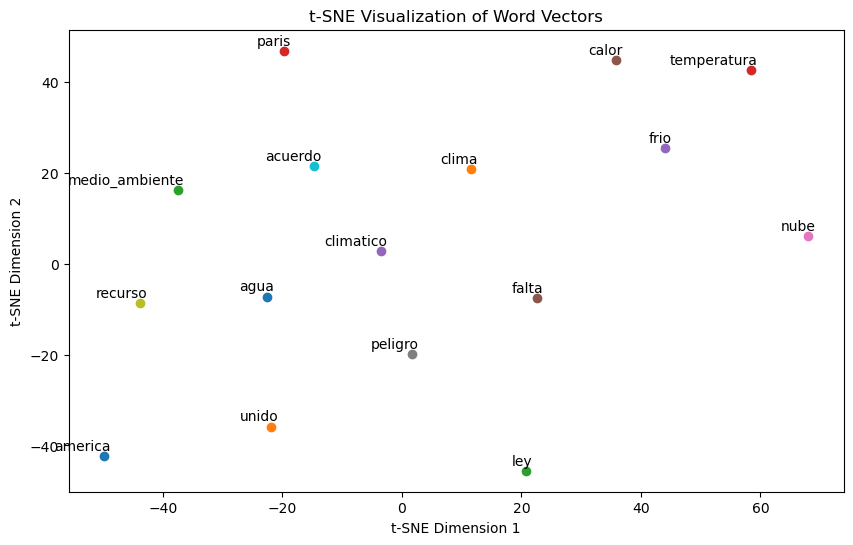

In [35]:
tsne_model = TSNE(n_components=2, random_state=42, perplexity=10)
tsne_vectors = tsne_model.fit_transform(word_vectors)

plt.figure(figsize=(10, 6))
for i, word in enumerate(words):
    plt.scatter(tsne_vectors[i, 0], tsne_vectors[i, 1])
    plt.annotate(word, xy=(tsne_vectors[i, 0], tsne_vectors[i, 1]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

plt.title('t-SNE Visualization of Word Vectors')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()